DATA PREPARATION


In [12]:
import kagglehub
path = kagglehub.dataset_download("sharmajicoder/why-gen-z-are-not-posting-on-social-media")

Using Colab cache for faster access to the 'why-gen-z-are-not-posting-on-social-media' dataset.


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [11]:
import os
import pandas as pd
import kagglehub

path = kagglehub.dataset_download("sharmajicoder/why-gen-z-are-not-posting-on-social-media")

# List files in the downloaded directory
files_in_dir = os.listdir(path)

# Find the first CSV file in the directory (assuming there's one main CSV)
csv_file_name = None
for f_name in files_in_dir:
    if f_name.endswith('.csv'):
        csv_file_name = f_name
        break

if csv_file_name:
    csv_file_path = os.path.join(path, csv_file_name)
    df = pd.read_csv(csv_file_path)
else:
    raise FileNotFoundError("No CSV file found in the dataset directory.")


Using Colab cache for faster access to the 'why-gen-z-are-not-posting-on-social-media' dataset.


In [16]:
df


,age,daily_screen_time,num_platforms_used,social_anxiety_score,self_esteem_score,privacy_concern,trend_fatigue,burnout_level,comparison_tendency,attention_span,posting_probability,is_active_poster,posting_decline_reason
0,22,3.050197,2,2,2,2,10,7,9,35,0.20,0,Low Interest
1,19,2.857721,1,4,10,0,5,3,1,31,0.42,1,Low Interest
2,28,5.714027,3,6,5,2,0,2,9,21,0.24,0,Low Interest
3,26,4.089610,3,1,6,0,6,7,2,9,0.35,1,Low Interest
4,23,3.593140,3,1,7,5,1,10,9,43,0.21,0,Burnout
...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,20,5.800782,4,5,3,1,1,3,4,7,0.23,0,Low Interest
999996,27,4.740434,4,5,9,7,7,10,10,20,0.09,0,Burnout
999997,29,5.236290,1,5,6,9,2,10,5,52,0.00,0,Privacy Concern
999998,22,4.973009,1,2,7,7,2,9,2,37,0.16,1,Burnout


In [ ]:
df.head()

,age,daily_screen_time,num_platforms_used,social_anxiety_score,self_esteem_score,privacy_concern,trend_fatigue,burnout_level,comparison_tendency,attention_span,posting_probability,is_active_poster,posting_decline_reason
0,22,3.050197,2,2,2,2,10,7,9,35,0.20,0,Low Interest
1,19,2.857721,1,4,10,0,5,3,1,31,0.42,1,Low Interest
2,28,5.714027,3,6,5,2,0,2,9,21,0.24,0,Low Interest
3,26,4.089610,3,1,6,0,6,7,2,9,0.35,1,Low Interest
4,23,3.593140,3,1,7,5,1,10,9,43,0.21,0,Burnout


In [ ]:
df.tail()

,age,daily_screen_time,num_platforms_used,social_anxiety_score,self_esteem_score,privacy_concern,trend_fatigue,burnout_level,comparison_tendency,attention_span,posting_probability,is_active_poster,posting_decline_reason
999995,20,5.800782,4,5,3,1,1,3,4,7,0.23,0,Low Interest
999996,27,4.740434,4,5,9,7,7,10,10,20,0.09,0,Burnout
999997,29,5.236290,1,5,6,9,2,10,5,52,0.00,0,Privacy Concern
999998,22,4.973009,1,2,7,7,2,9,2,37,0.16,1,Burnout
999999,24,6.322569,1,4,10,7,6,5,8,43,0.24,0,Low Interest


In [ ]:
df.shape

(1000000, 13)

In [ ]:
df.describe()

,age,daily_screen_time,num_platforms_used,social_anxiety_score,self_esteem_score,privacy_concern,trend_fatigue,burnout_level,comparison_tendency,attention_span,posting_probability,is_active_poster
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000
mean,22.494254,4.001982,3.000246,4.996911,5.002528,4.999908,5.001389,5.003304,5.003456,31.984325,0.161305,0.161899
std,4.031665,1.495497,1.414307,3.163908,3.161290,3.161279,3.161241,3.162251,3.161952,15.856177,0.127367,0.368358
min,16.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,0.000000,0.000000
25%,19.000000,2.988697,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,18.000000,0.050000,0.000000
50%,22.000000,4.000457,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,32.000000,0.150000,0.000000
75%,26.000000,5.008822,4.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,46.000000,0.250000,0.000000
max,29.000000,10.992968,5.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,59.000000,0.600000,1.000000


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 13 columns):
 #   Column                  Non-Null Count    Dtype  
---  ------                  --------------    -----  
 0   age                     1000000 non-null  int64  
 1   daily_screen_time       1000000 non-null  float64
 2   num_platforms_used      1000000 non-null  int64  
 3   social_anxiety_score    1000000 non-null  int64  
 4   self_esteem_score       1000000 non-null  int64  
 5   privacy_concern         1000000 non-null  int64  
 6   trend_fatigue           1000000 non-null  int64  
 7   burnout_level           1000000 non-null  int64  
 8   comparison_tendency     1000000 non-null  int64  
 9   attention_span          1000000 non-null  int64  
 10  posting_probability     1000000 non-null  float64
 11  is_active_poster        1000000 non-null  int64  
 12  posting_decline_reason  1000000 non-null  object 
dtypes: float64(2), int64(10), object(1)
memory usage: 99.2+ MB

In [ ]:
print('Missing values in each column:')
df.isnull().sum()

Missing values in each column:


,0
age,0
daily_screen_time,0
num_platforms_used,0
social_anxiety_score,0
self_esteem_score,0
privacy_concern,0
trend_fatigue,0
burnout_level,0
comparison_tendency,0
attention_span,0


Distribusi Gen Z aktif memposting


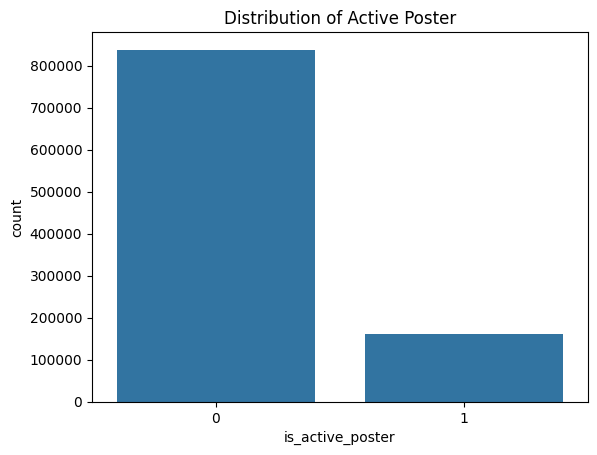

In [18]:
print('Distribusi Gen Z aktif memposting')
sns.countplot(x='is_active_poster', data=df)
plt.title('Distribution of Active Poster')
plt.show()

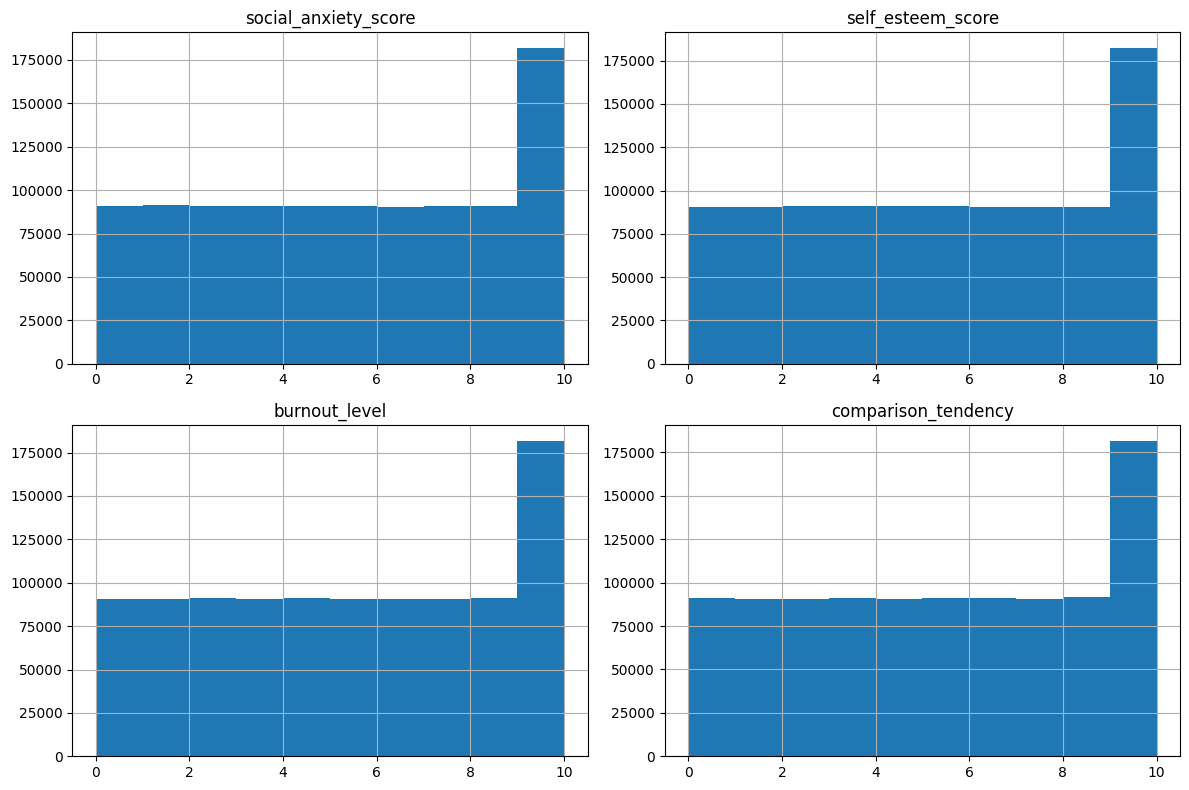

In [7]:
selected_features = [
    'social_anxiety_score',
    'self_esteem_score',
    'burnout_level',
    'comparison_tendency'
]

df[selected_features].hist(figsize=(12,8))

plt.tight_layout()
plt.show()

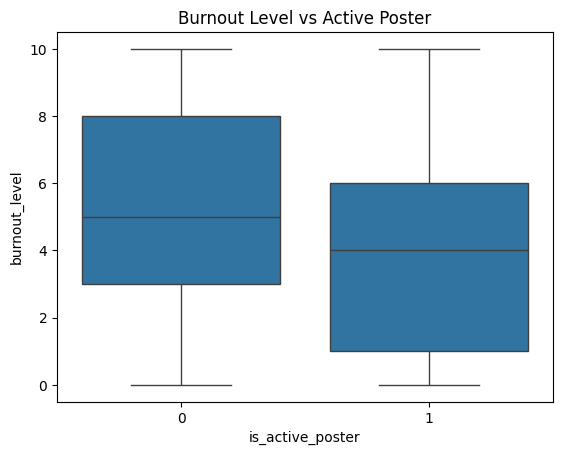

In [ ]:
sns.boxplot(
    x='is_active_poster',
    y='burnout_level',
    data=df
)

plt.title('Burnout Level vs Active Poster')
plt.show()

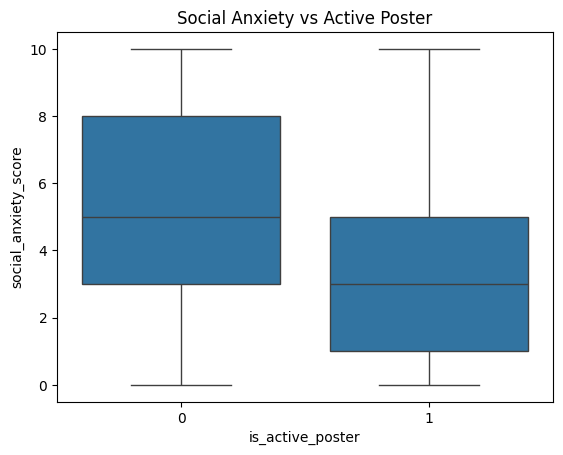

In [ ]:
sns.boxplot(
    x='is_active_poster',
    y='social_anxiety_score',
    data=df
)

plt.title('Social Anxiety vs Active Poster')
plt.show()

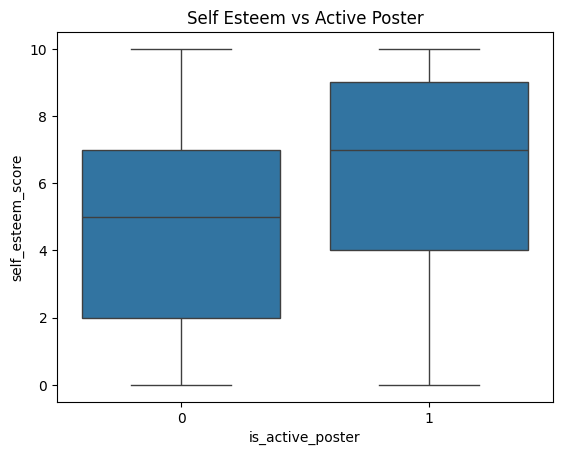

In [ ]:
sns.boxplot(
    x='is_active_poster',
    y='self_esteem_score',
    data=df
)

plt.title('Self Esteem vs Active Poster')
plt.show()

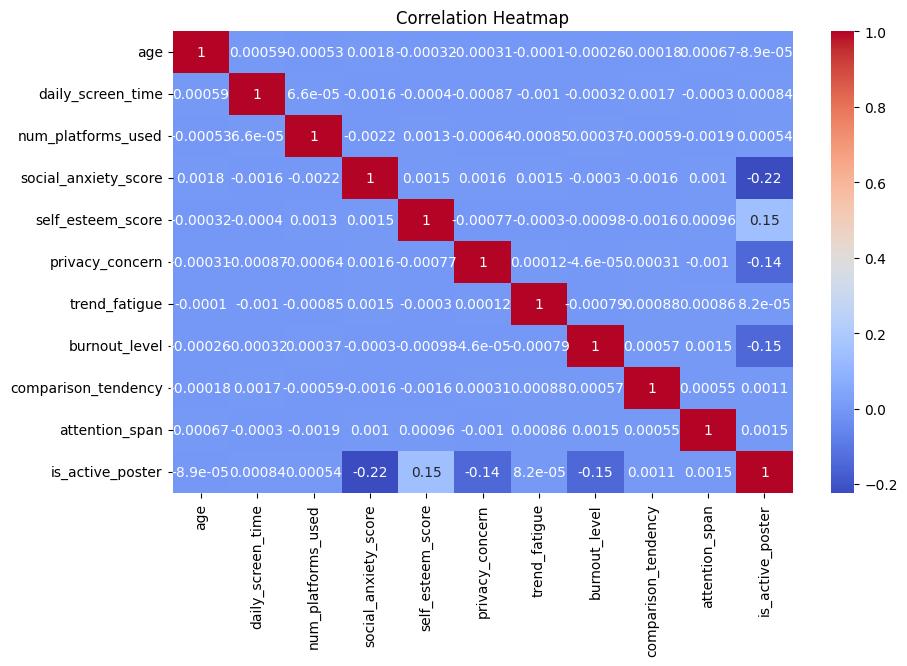

In [ ]:
selected_columns = [
    'age',
    'daily_screen_time',
    'num_platforms_used',
    'social_anxiety_score',
    'self_esteem_score',
    'privacy_concern',
    'trend_fatigue',
    'burnout_level',
    'comparison_tendency',
    'attention_span',
    'is_active_poster'
]

plt.figure(figsize=(10,6))

sns.heatmap(
    df[selected_columns].corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')
plt.show()

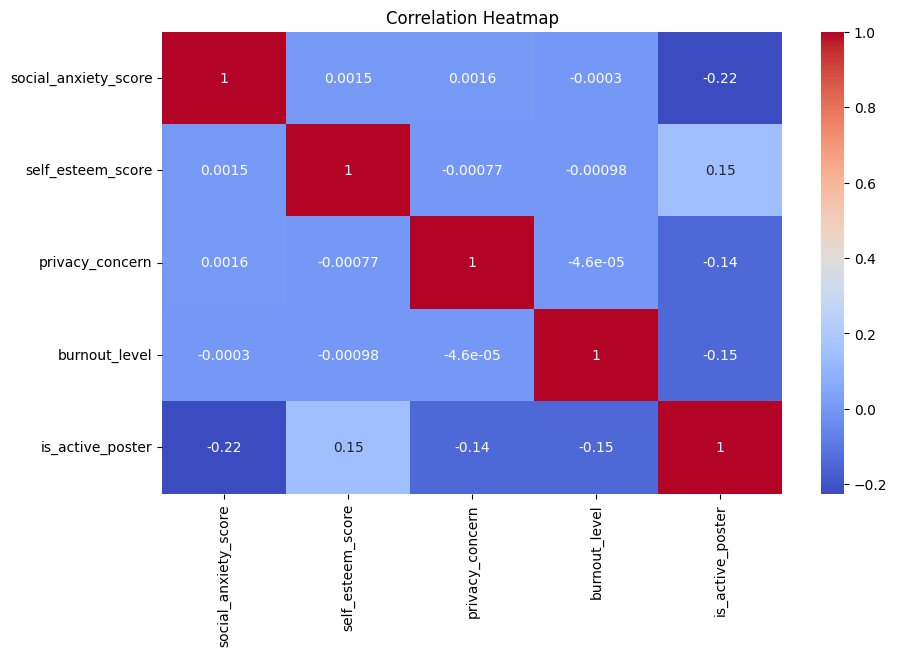

In [8]:
selected_columns = [
    'social_anxiety_score',
    'self_esteem_score',
    'privacy_concern',
    'burnout_level',
    'is_active_poster'
]

plt.figure(figsize=(10,6))

sns.heatmap(
    df[selected_columns].corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')
plt.show()

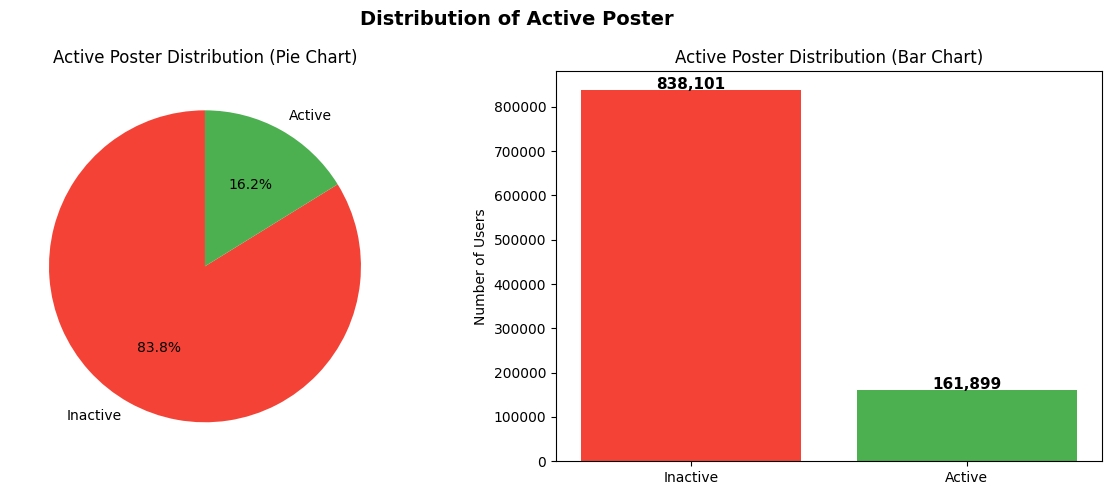

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

fig.suptitle(
    'Distribution of Active Poster',
    fontsize=14,
    fontweight='bold'
)

# Hitung jumlah kategori
counts = df['is_active_poster'].value_counts()

# Label lebih readable
labels = ['Inactive', 'Active']

# Warna
colors = ['#F44336', '#4CAF50']

# ======================
# Pie Chart
# ======================

axes[0].pie(
    counts,
    labels=labels,
    autopct='%1.1f%%',
    colors=colors,
    startangle=90
)

axes[0].set_title('Active Poster Distribution (Pie Chart)')

# ======================
# Bar Chart
# ======================

bars = axes[1].bar(
    labels,
    counts.values,
    color=colors
)

axes[1].set_title('Active Poster Distribution (Bar Chart)')
axes[1].set_ylabel('Number of Users')

# Tambah angka di atas bar
for bar, val in zip(bars, counts.values):
    axes[1].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 1000,
        f'{val:,}',
        ha='center',
        fontsize=11,
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

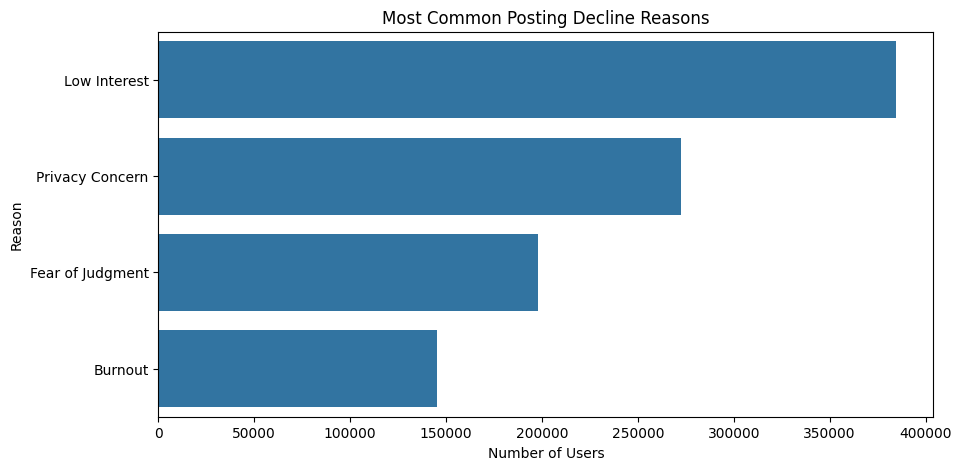

In [ ]:
plt.figure(figsize=(10,5))


counts = df['posting_decline_reason'].value_counts()

sns.barplot(
    x=counts.values,
    y=counts.index
)

plt.title('Most Common Posting Decline Reasons')
plt.xlabel('Number of Users')
plt.ylabel('Reason')

plt.show()

DATA PROCESSING

In [20]:
print("🔍 Missing values per kolom:")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "✅ Tidak ada missing values!")

print(f"\n🔍 Total duplikat: {df.duplicated().sum()} baris")


🔍 Missing values per kolom:
✅ Tidak ada missing values!

🔍 Total duplikat: 0 baris


In [21]:
features = [
    'age',
    'daily_screen_time',
    'num_platforms_used',
    'social_anxiety_score',
    'self_esteem_score',
    'privacy_concern',
    'trend_fatigue',
    'burnout_level',
    'comparison_tendency',
    'attention_span'
]

X = df[features]

y = df['is_active_poster']

In [ ]:
df.dtypes

,0
age,int64
daily_screen_time,float64
num_platforms_used,int64
social_anxiety_score,int64
self_esteem_score,int64
privacy_concern,int64
trend_fatigue,int64
burnout_level,int64
comparison_tendency,int64
attention_span,int64


In [22]:
from sklearn.preprocessing import StandardScaler

# ============================================================
# Scaling Feature
# ============================================================

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# ============================================================
# Menampilkan hasil scaling
# ============================================================

print("📌 Range tiap fitur SETELAH scaling:\n")

for i, f in enumerate(features):
    col = X_scaled[:, i]

    print(
        f"{f:25s}: "
        f"{col.min():>6.2f} → {col.max():>6.2f} "
        f"(mean: {col.mean():>6.2f}, std: {col.std():>5.2f})"
    )

print("\n✅ Semua fitur sekarang memiliki skala yang setara dan siap digunakan untuk proses machine learning.")

📌 Range tiap fitur SETELAH scaling:

age                      :  -1.61 →   1.61 (mean:  -0.00, std:  1.00)
daily_screen_time        :  -2.68 →   4.67 (mean:   0.00, std:  1.00)
num_platforms_used       :  -1.41 →   1.41 (mean:  -0.00, std:  1.00)
social_anxiety_score     :  -1.58 →   1.58 (mean:   0.00, std:  1.00)
self_esteem_score        :  -1.58 →   1.58 (mean:   0.00, std:  1.00)
privacy_concern          :  -1.58 →   1.58 (mean:   0.00, std:  1.00)
trend_fatigue            :  -1.58 →   1.58 (mean:   0.00, std:  1.00)
burnout_level            :  -1.58 →   1.58 (mean:   0.00, std:  1.00)
comparison_tendency      :  -1.58 →   1.58 (mean:   0.00, std:  1.00)
attention_span           :  -1.70 →   1.70 (mean:   0.00, std:  1.00)

✅ Semua fitur sekarang memiliki skala yang setara dan siap digunakan untuk proses machine learning.


In [23]:
print("📌 Range fitur SEBELUM scaling:\n")

for f in features:
    print(
        f"{f:25s}: "
        f"{X[f].min():>6.2f} → {X[f].max():>6.2f}"
    )

📌 Range fitur SEBELUM scaling:

age                      :  16.00 →  29.00
daily_screen_time        :   0.00 →  10.99
num_platforms_used       :   1.00 →   5.00
social_anxiety_score     :   0.00 →  10.00
self_esteem_score        :   0.00 →  10.00
privacy_concern          :   0.00 →  10.00
trend_fatigue            :   0.00 →  10.00
burnout_level            :   0.00 →  10.00
comparison_tendency      :   0.00 →  10.00
attention_span           :   5.00 →  59.00


In [24]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

LOGISTIC REGRRESSION

In [26]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Membuat model
lr_model = LogisticRegression()

# Training
lr_model.fit(X_train, y_train)

# Prediksi
y_pred_lr = lr_model.predict(X_test)

# Evaluasi
lr_accuracy = accuracy_score(y_test, y_pred_lr)

print("Logistic Regression Accuracy:", lr_accuracy)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.83472

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.98      0.91    167413
           1       0.46      0.08      0.14     32587

    accuracy                           0.83    200000
   macro avg       0.65      0.53      0.53    200000
weighted avg       0.78      0.83      0.78    200000



DECISION TREE

In [27]:
from sklearn.tree import DecisionTreeClassifier

# Membuat model
dt_model = DecisionTreeClassifier(random_state=42)

# Training
dt_model.fit(X_train, y_train)

# Prediksi
y_pred_dt = dt_model.predict(X_test)

# Evaluasi
dt_accuracy = accuracy_score(y_test, y_pred_dt)

print("Decision Tree Accuracy:", dt_accuracy)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))

Decision Tree Accuracy: 0.74897

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.84      0.85    167413
           1       0.26      0.29      0.27     32587

    accuracy                           0.75    200000
   macro avg       0.56      0.56      0.56    200000
weighted avg       0.76      0.75      0.75    200000



RANDOM FOREST

In [28]:
from sklearn.ensemble import RandomForestClassifier

# Membuat model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Training
rf_model.fit(X_train, y_train)

# Prediksi
y_pred_rf = rf_model.predict(X_test)

# Evaluasi
rf_accuracy = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", rf_accuracy)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.8347

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.99      0.91    167413
           1       0.43      0.04      0.08     32587

    accuracy                           0.83    200000
   macro avg       0.63      0.52      0.49    200000
weighted avg       0.77      0.83      0.77    200000



In [29]:
model_results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest'
    ],
    'Accuracy': [
        lr_accuracy,
        dt_accuracy,
        rf_accuracy
    ]
})

model_results

,Model,Accuracy
0,Logistic Regression,0.83472
1,Decision Tree,0.74897
2,Random Forest,0.83470


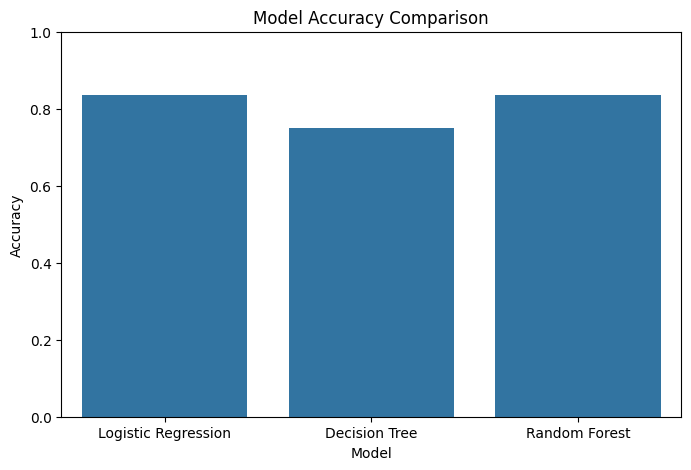

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    x='Model',
    y='Accuracy',
    data=model_results
)

plt.title('Model Accuracy Comparison')
plt.ylim(0,1)

plt.show()

CONFUSION MATRIX

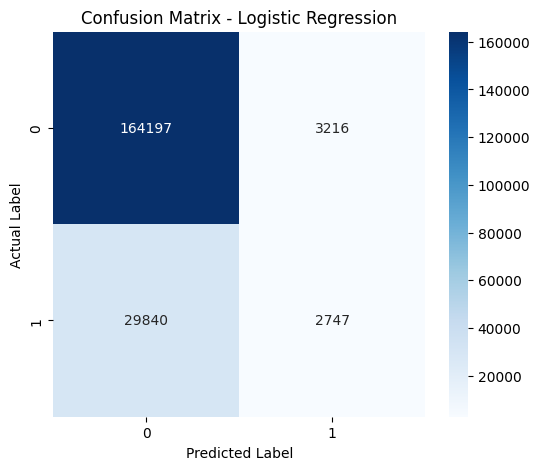

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')

plt.show()

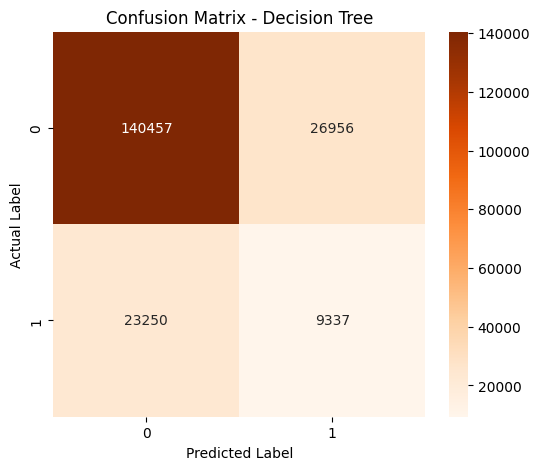

In [30]:
from sklearn.metrics import confusion_matrix

cm_dt = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_dt,
    annot=True,
    fmt='d',
    cmap='Oranges'
)

plt.title('Confusion Matrix - Decision Tree')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')

plt.show()

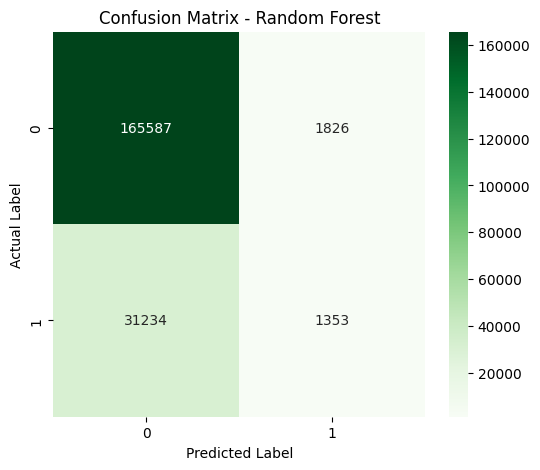

In [31]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')

plt.show()

PRDIKSI DATA BARU

In [ ]:
new_data = pd.DataFrame({
    'age': [21],
    'daily_screen_time': [8],
    'num_platforms_used': [4],
    'social_anxiety_score': [8],
    'self_esteem_score': [3],
    'privacy_concern': [1],  # sesuaikan hasil encoding
    'trend_fatigue': [7],
    'burnout_level': [8],
    'comparison_tendency': [9],
    'attention_span': [4]
})

In [ ]:
new_data_scaled = scaler.transform(new_data)

In [ ]:
prediction = lr_model.predict(new_data_scaled)

print("Prediction:", prediction)

Prediction: [0]


In [ ]:
if prediction[0] == 1:
    print("User is predicted as Active Poster")
else:
    print("User is predicted as Inactive Poster")

User is predicted as Inactive Poster


              Model  Accuracy  Precision   Recall  F1 Score
      Decision Tree   0.74897   0.257267 0.286525  0.271109
      Random Forest   0.83470   0.425606 0.041520  0.075658
Logistic Regression   0.83472   0.460674 0.084297  0.142516


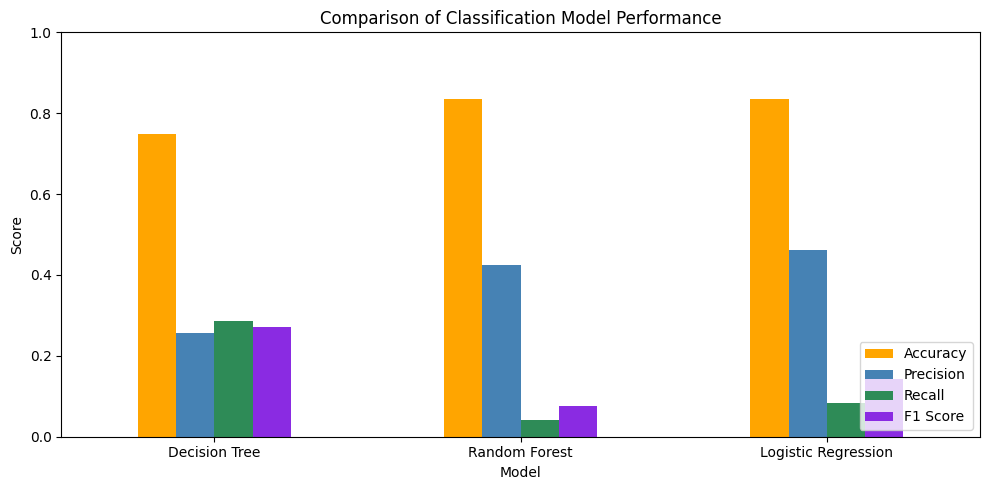

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# ============================================================
# Perbandingan Performa Model
# ============================================================

results = pd.DataFrame({
    'Model': [
        'Decision Tree',
        'Random Forest',
        'Logistic Regression'
    ],

    'Accuracy': [
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_lr)
    ],

    'Precision': [
        precision_score(y_test, y_pred_dt),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_lr)
    ],

    'Recall': [
        recall_score(y_test, y_pred_dt),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_lr)
    ],

    'F1 Score': [
        f1_score(y_test, y_pred_dt),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_lr)
    ]
})

# ============================================================
# Tampilkan Tabel Hasil
# ============================================================

print(results.to_string(index=False))

# ============================================================
# Visualisasi Perbandingan Model
# ============================================================

results.set_index('Model').plot(
    kind='bar',
    figsize=(10, 5),
    color=['#FFA500', '#4682B4', '#2E8B57', '#8A2BE2']
)

plt.title('Comparison of Classification Model Performance')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.ylim(0, 1)

plt.legend(loc='lower right')

plt.tight_layout()
plt.show()